In [9]:
# # Fresh test: one questioned document and three references
#
# These setup cells create and validate a controlled case in Google Drive.
# After Cell 5, continue through the existing Branch 1 processing cells. Reuse
# the `RUN_DIRECTORY`, `INPUT_DOCUMENT_PATH`, and `REFERENCE_IMAGE_PATHS`
# variables created here.

# %% [markdown]
# ## Cell 1 — Mount Drive and define the case folders

# %%
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/Signature-Forensic-Prototype"
)
CASE_DIRECTORY = (
    PROJECT_DIRECTORY
    / "data/cases/three_reference_test"
)
QUESTIONED_DIRECTORY = CASE_DIRECTORY / "questioned"
REFERENCE_DIRECTORY = CASE_DIRECTORY / "references"
OUTPUT_ROOT = PROJECT_DIRECTORY / "outputs"
CONFIG_PATH = PROJECT_DIRECTORY / "config.yaml"

for directory in (
    QUESTIONED_DIRECTORY,
    REFERENCE_DIRECTORY,
    OUTPUT_ROOT,
):
    directory.mkdir(parents=True, exist_ok=True)

print("Questioned input folder:", QUESTIONED_DIRECTORY)
print("Reference folder:", REFERENCE_DIRECTORY)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Questioned input folder: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/questioned
Reference folder: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references


In [19]:
# ## Cell 2 — Option A: upload one questioned document
#
# Skip this cell if the document is already in the Drive folder. Supported
# formats are PDF, PNG, JPG, and JPEG.

# %%
from google.colab import files
import shutil

print("Select exactly one questioned document.")
uploaded_questioned = files.upload()

if len(uploaded_questioned) != 1:
    raise ValueError("Upload exactly one questioned document.")

questioned_name = next(iter(uploaded_questioned))
questioned_suffix = Path(questioned_name).suffix.lower()
if questioned_suffix not in {".pdf", ".png", ".jpg", ".jpeg"}:
    raise ValueError(
        "Questioned input must be PDF, PNG, JPG, or JPEG."
    )

questioned_destination = (
    QUESTIONED_DIRECTORY / questioned_name
)
shutil.copy2(
    Path("/content") / questioned_name,
    questioned_destination,
)
print("Saved:", questioned_destination)

Select exactly one questioned document.


Saving Questioned Image.jpeg to Questioned Image (1).jpeg
Saved: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/questioned/Questioned Image (1).jpeg


In [20]:
# ## Cell 3 — Option A: upload exactly three reference signatures
#
# Select all three files in the same upload dialog. Existing images in the
# reference folder are not deleted automatically.

# %%
print("Select exactly three reference signature images.")
uploaded_references = files.upload()

if len(uploaded_references) != 3:
    raise ValueError("Upload exactly three reference images.")

for reference_name in uploaded_references:
    suffix = Path(reference_name).suffix.lower()
    if suffix not in {".png", ".jpg", ".jpeg"}:
        raise ValueError(
            f"Unsupported reference image: {reference_name}"
        )
    destination = REFERENCE_DIRECTORY / reference_name
    shutil.copy2(
        Path("/content") / reference_name,
        destination,
    )
    print("Saved:", destination)

Select exactly three reference signature images.


Saving Referenced Image 1.jpeg to Referenced Image 1.jpeg
Saving Referenced Image 2.jpeg to Referenced Image 2 (2).jpeg
Saving Referenced Image 3.jpeg to Referenced Image 3 (2).jpeg
Saved: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 1.jpeg
Saved: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 2 (2).jpeg
Saved: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 3 (2).jpeg


In [21]:
# ## Cell 4 — Validate the case inputs
#
# If you copied the files directly through Google Drive, start at this cell.
# The validation prevents accidentally mixing multiple questioned documents or
# using the wrong number of references.

# %%
import hashlib
from PIL import Image

questioned_candidates = sorted(
    path
    for path in QUESTIONED_DIRECTORY.iterdir()
    if path.suffix.lower() in {".pdf", ".png", ".jpg", ".jpeg"}
)
REFERENCE_IMAGE_PATHS = sorted(
    path
    for path in REFERENCE_DIRECTORY.iterdir()
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}
)

if len(questioned_candidates) != 1:
    raise ValueError(
        "The questioned folder must contain exactly one supported "
        f"document; found {len(questioned_candidates)}."
    )
if len(REFERENCE_IMAGE_PATHS) != 3:
    raise ValueError(
        "The references folder must contain exactly three images; "
        f"found {len(REFERENCE_IMAGE_PATHS)}."
    )

INPUT_DOCUMENT_PATH = questioned_candidates[0]
PAGE_NUMBER = 0

reference_hashes = []
for reference_path in REFERENCE_IMAGE_PATHS:
    with Image.open(reference_path) as image:
        image.verify()
    digest = hashlib.sha256(
        reference_path.read_bytes()
    ).hexdigest()
    reference_hashes.append(digest)

if len(set(reference_hashes)) != 3:
    raise ValueError(
        "Two or more reference files are exact duplicates."
    )

print("Questioned document:", INPUT_DOCUMENT_PATH)
print("Page:", PAGE_NUMBER)
print("Validated reference signatures:")
for index, reference_path in enumerate(
    REFERENCE_IMAGE_PATHS,
    start=1,
):
    print(f"{index}. {reference_path}")

Questioned document: /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/questioned/Questioned Image (1).jpeg
Page: 0
Validated reference signatures:
1. /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 1.jpeg
2. /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 2 (2).jpeg
3. /content/drive/MyDrive/Signature-Forensic-Prototype/data/cases/three_reference_test/references/Referenced Image 3 (2).jpeg


In [22]:
# ## Cell 5 — Create a new output run and save its manifest
#
# This isolates the new experiment from previous five-reference results.

# %%
from datetime import datetime, timezone
import json

RUN_ID = datetime.now(timezone.utc).strftime(
    "%Y%m%dT%H%M%S_%fZ"
)
RUN_DIRECTORY = OUTPUT_ROOT / RUN_ID
RUN_DIRECTORY.mkdir(parents=True, exist_ok=False)

CASE_MANIFEST_PATH = RUN_DIRECTORY / "case_manifest.json"
case_manifest = {
    "run_id": RUN_ID,
    "experiment": "one_questioned_three_references",
    "questioned_document": str(INPUT_DOCUMENT_PATH),
    "page_number": PAGE_NUMBER,
    "reference_count": len(REFERENCE_IMAGE_PATHS),
    "reference_images": [
        str(path) for path in REFERENCE_IMAGE_PATHS
    ],
    "important_interpretation": (
        "The three references must represent the same claimed writer "
        "and signature form. Pipeline results are review-priority "
        "indicators, not authenticity or forgery findings."
    ),
}
CASE_MANIFEST_PATH.write_text(
    json.dumps(case_manifest, indent=2),
    encoding="utf-8",
)

print("New run directory:", RUN_DIRECTORY)
print("Manifest saved:", CASE_MANIFEST_PATH)

New run directory: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z
Manifest saved: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/case_manifest.json


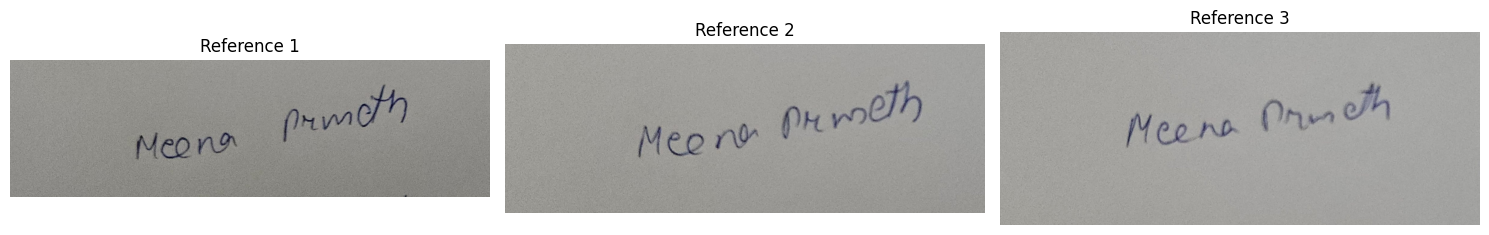

Setup completed. Continue with Branch 1 document loading using:
- INPUT_DOCUMENT_PATH
- PAGE_NUMBER
- REFERENCE_IMAGE_PATHS
- RUN_DIRECTORY


In [23]:
# %% [markdown]
# ## Cell 6 — Display the three references before analysis
#
# Visually confirm that they belong to the intended writer, are upright, and
# are not accidental duplicates.

# %%
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for index, (axis, reference_path) in enumerate(
    zip(axes, REFERENCE_IMAGE_PATHS),
    start=1,
):
    axis.imshow(Image.open(reference_path).convert("RGB"))
    axis.set_title(f"Reference {index}")
    axis.axis("off")
plt.tight_layout()
plt.show()

print(
    "Setup completed. Continue with Branch 1 document loading using:\n"
    "- INPUT_DOCUMENT_PATH\n"
    "- PAGE_NUMBER\n"
    "- REFERENCE_IMAGE_PATHS\n"
    "- RUN_DIRECTORY"
)

In [25]:
# ## Fresh Runner Cell 1 — Install inference dependencies
#
# Training packages and datasets are not used. SAM may download its configured
# pretrained model into the temporary Colab cache.

# %%
import subprocess
import sys

REQUIREMENTS_PATH = (
    PROJECT_DIRECTORY / "requirements.txt"
)

if REQUIREMENTS_PATH.is_file():
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ]
    print("Installing from:", REQUIREMENTS_PATH)
else:
    # A direct-package fallback makes the fresh runner usable even when only
    # src/, config.yaml, and the trained models were copied to Google Drive.
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy>=1.26,<3",
        "PyYAML>=6.0,<7",
        "Pillow>=10.0,<12",
        "opencv-python-headless>=4.9,<5",
        "PyMuPDF>=1.24,<2",
        "scikit-image>=0.22,<1",
        "scipy>=1.11,<2",
        "ImageHash>=4.3,<5",
        "ultralytics>=8.3,<9",
        "torch>=2.2,<3",
        "torchvision>=0.17,<1",
        "transformers>=4.45,<6",
        "safetensors>=0.4,<1",
        "scikit-learn>=1.4,<2",
        "matplotlib>=3.8,<4",
        "openai>=1.50,<3",
    ]
    print(
        "requirements.txt was not found; installing the "
        "inference packages directly."
    )

subprocess.run(
    install_command,
    check=True,
)

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Inference device:", DEVICE)
print("Run directory:", RUN_DIRECTORY)
print("References:", len(REFERENCE_IMAGE_PATHS))


requirements.txt was not found; installing the inference packages directly.
Inference device: cuda
Run directory: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z
References: 3


In [26]:
# %% [markdown]
# ## Fresh Runner Cell 2 — Import the reusable branch functions

# %%
import importlib
import sys

if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

for module_name in list(sys.modules):
    if module_name == "src.fresh_case_pipeline":
        del sys.modules[module_name]

importlib.invalidate_caches()

from src.fresh_case_pipeline import (
    run_branch1_fresh,
    run_branch2_fresh,
    run_branch3_fresh,
)

print("Fresh inference runners imported.")

Fresh inference runners imported.


In [28]:
# ## Fresh Runner Cell 1 — Install inference dependencies
#
# Training packages and datasets are not used. SAM may download its configured
# pretrained model into the temporary Colab cache.

# %%
import subprocess
import sys

REQUIREMENTS_PATH = (
    PROJECT_DIRECTORY / "requirements.txt"
)

if REQUIREMENTS_PATH.is_file():
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ]
    print("Installing from:", REQUIREMENTS_PATH)
else:
    # A direct-package fallback makes the fresh runner usable even when only
    # src/, config.yaml, and the trained models were copied to Google Drive.
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy>=1.26,<3",
        "PyYAML>=6.0,<7",
        "Pillow>=10.0,<12",
        "opencv-python-headless>=4.9,<5",
        "PyMuPDF>=1.24,<2",
        "scikit-image>=0.22,<1",
        "scipy>=1.11,<2",
        "ImageHash>=4.3,<5",
        "ultralytics>=8.3,<9",
        "torch>=2.2,<3",
        "torchvision>=0.17,<1",
        "transformers>=4.45,<6",
        "safetensors>=0.4,<1",
        "scikit-learn>=1.4,<2",
        "matplotlib>=3.8,<4",
        "openai>=1.50,<3",
    ]
    print(
        "requirements.txt was not found; installing the "
        "inference packages directly."
    )

subprocess.run(
    install_command,
    check=True,
)

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Inference device:", DEVICE)
print("Run directory:", RUN_DIRECTORY)
print("References:", len(REFERENCE_IMAGE_PATHS))



requirements.txt was not found; installing the inference packages directly.
Inference device: cuda
Run directory: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z
References: 3
Fresh inference runners imported.


In [30]:
# %% [markdown]
# ## Fresh Runner Cell 2 — Import the reusable branch functions

# %%
import importlib
import sys

if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

for module_name in list(sys.modules):
    if module_name == "src.fresh_case_pipeline":
        del sys.modules[module_name]

importlib.invalidate_caches()

from src.fresh_case_pipeline import (
    run_branch1_fresh,
    run_branch2_fresh,
    run_branch3_fresh,
)

print("Fresh inference runners imported.")

Fresh inference runners imported.


In [31]:
# ## Fresh Runner Cell 3 — Run Branch 1
#
# Set `ACCEPTED_DETECTION_NUMBER` to the one-based YOLO detection that contains
# the questioned signature. Use `1` when the page has only one correct
# detection. The result is saved directly into the current run directory.
#
# This cell performs document processing, YOLO inference, SAM segmentation,
# conservative cleaning, saved-Siamese inference, Branch 1 explainable
# measurements, and Branch 1 risk fusion. It does not train any model.

# %%
ACCEPTED_DETECTION_NUMBER = 1

# First retry at 0.10 if the normal 0.25 threshold produced no boxes.
# Do not reduce this automatically below 0.10 because false detections become
# increasingly likely.
DETECTION_CONFIDENCE_OVERRIDE = 0.10

# Leave this as None when YOLO detects the correct signature. If it still
# returns no candidates, inspect 02_preprocessed_page.png and enter the pixel
# coordinates as [left, top, right, bottom], for example [120, 250, 420, 340].
MANUAL_SIGNATURE_BOX = None

branch1_fresh = run_branch1_fresh(
    questioned_document=INPUT_DOCUMENT_PATH,
    reference_paths=REFERENCE_IMAGE_PATHS,
    run_directory=RUN_DIRECTORY,
    config_path=CONFIG_PATH,
    accepted_detection_number=ACCEPTED_DETECTION_NUMBER,
    page_number=PAGE_NUMBER,
    device=DEVICE,
    detection_confidence_override=(
        DETECTION_CONFIDENCE_OVERRIDE
    ),
    manual_signature_bbox_xyxy=MANUAL_SIGNATURE_BOX,
)

print("BRANCH 1 COMPLETED")
print("==================")
print(
    "Accepted box:",
    branch1_fresh["accepted_detection"]["bbox_xyxy"],
)
print(
    "Detection confidence:",
    branch1_fresh["accepted_detection"]["confidence"],
)
print(
    "Verification:",
    branch1_fresh["verification_result"],
)
print(
    "Branch 1 decision:",
    branch1_fresh["risk_result"]["decision"],
)
print(
    "Branch 1 risk:",
    branch1_fresh["risk_result"]["overall_risk"],
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

BRANCH 1 COMPLETED
Accepted box: [467, 298, 718, 412]
Detection confidence: 0.204096
Verification: {'reference_scores': [0.478225, 0.382284, 0.407726], 'mean_similarity': 0.422745, 'median_similarity': 0.407726, 'minimum_similarity': 0.382284, 'maximum_similarity': 0.478225, 'score_spread': 0.095941, 'verification_status': 'elevated_inconsistency', 'input_quality': {'passed': True, 'quality_score': 1.0, 'foreground_removal_ratio': 0.0, 'original_components': 2, 'cleaned_components': 2, 'original_endpoints': 22, 'cleaned_endpoints': 15, 'endpoint_change_ratio': 0.318182, 'fallback_used': False, 'fallback_reason': None, 'warnings': []}}
Branch 1 decision: manual_review
Branch 1 risk: 0.352259


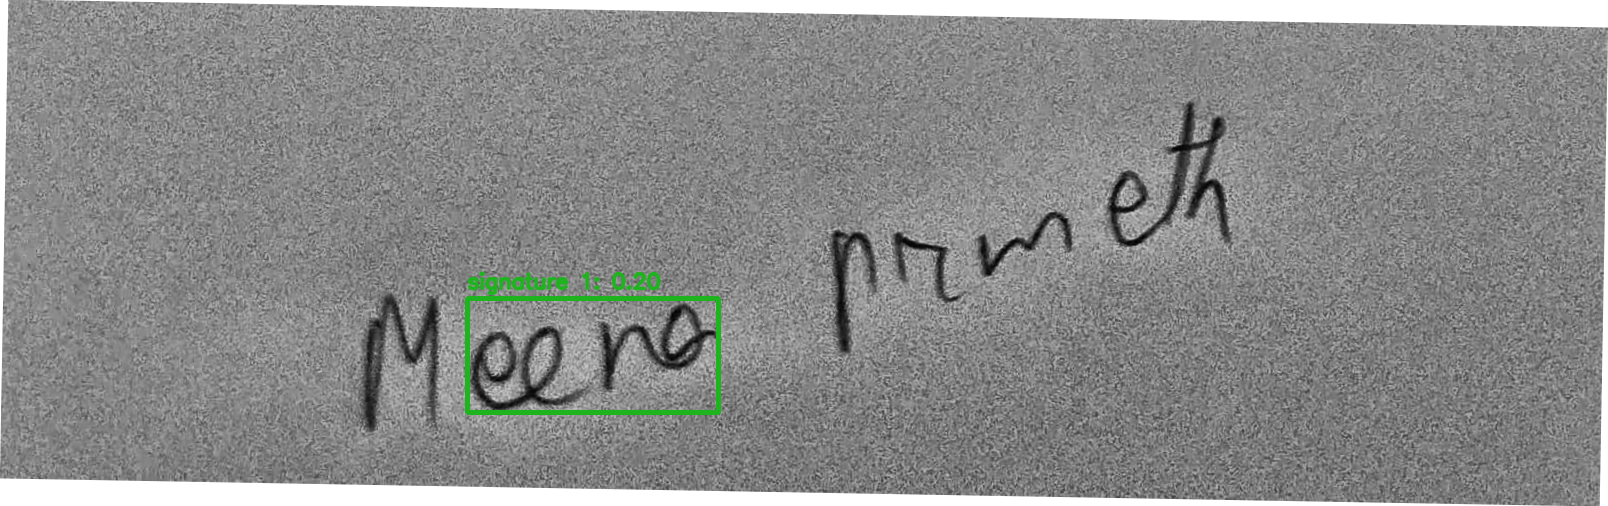

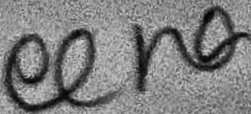

In [32]:
# %% [markdown]
# ## Fresh Runner Cell 4 — Inspect the Branch 1 detection
#
# Stop here if the displayed box is not the intended signature. Change
# `ACCEPTED_DETECTION_NUMBER`, delete this new run, and rerun Branch 1 rather
# than allowing an incorrect crop into the other branches.

# %%
from PIL import Image
from IPython.display import display

display(
    Image.open(
        RUN_DIRECTORY / "03_yolo_detection.png"
    )
)
display(
    Image.open(
        branch1_fresh["accepted_crop_path"]
    )
)

In [33]:
# ## Fresh Runner Cell 5 — Run Branch 2 Structural AI

# %%
branch2_fresh = run_branch2_fresh(
    cleaned_questioned_signature=branch1_fresh[
        "cleaning_result"
    ]["cleaned_signature"],
    reference_paths=REFERENCE_IMAGE_PATHS,
    run_directory=RUN_DIRECTORY,
    config_path=CONFIG_PATH,
)

print("BRANCH 2 COMPLETED")
print("==================")
print(
    branch2_fresh["result"]["reference_variation"]
)
print(
    "Saved:",
    branch2_fresh["saved"]["report"],
)

BRANCH 2 COMPLETED
{'questioned_mean': 0.58423187, 'questioned_median': 0.58977695, 'questioned_minimum': 0.5554656, 'questioned_maximum': 0.60745307, 'reference_pair_count': 3, 'reference_similarity_median': 0.66175204, 'reference_similarity_10th_percentile': 0.63057609, 'relative_status': 'below_observed_reference_variation'}
Saved: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch2_geometry/branch2_geometry_result.json


In [34]:
# ## Fresh Runner Cell 6 — Run Branch 3 Document Forensics

# %%
branch3_fresh = run_branch3_fresh(
    original_page=branch1_fresh[
        "document_result"
    ]["original_image"],
    signature_bbox_xyxy=branch1_fresh[
        "accepted_detection"
    ]["bbox_xyxy"],
    reference_paths=REFERENCE_IMAGE_PATHS,
    run_directory=RUN_DIRECTORY,
    config_path=CONFIG_PATH,
)

print("BRANCH 3 COMPLETED")
print("==================")
print(branch3_fresh["result"]["risk"])
print(
    "Saved:",
    branch3_fresh["saved"]["report"],
)

BRANCH 3 COMPLETED
{'component_risks': {'copy_paste': 0.020313, 'compression': 0.088436, 'noise': 0.255622, 'duplicate': 0.0}, 'normalized_weights': {'copy_paste': 0.35, 'compression': 0.2, 'noise': 0.2, 'duplicate': 0.25}, 'overall_screening_risk': 0.075921, 'evidence_availability': {'orb_crop_to_page': True, 'multiscale_template': True, 'compression': True, 'noise': True, 'reference_hashing': True, 'reference_orb_available_count': 3, 'reference_comparison_count': 3}, 'evidence_coverage': 1.0, 'decision': 'no_elevated_indicators', 'reasons': ['No configured screening threshold was exceeded; editing is not ruled out'], 'warnings': ['ELA is a screening indicator. PDF rendering, scanning, image resizing, and repeated compression can produce similar patterns.', 'Noise inconsistency is not specific to editing. Ink density, paper texture, shadows, scanning, and compression can change residuals.'], 'disclaimer': 'Branch 3 reports document-forensics screening indicators. It does not prove or 

In [35]:
# ## Fresh Runner Cell 7 — Verify the three canonical results

# %%
required_results = {
    "Branch 1": RUN_DIRECTORY / "risk_fusion_result.json",
    "Branch 2": (
        RUN_DIRECTORY
        / "branch2_geometry/branch2_geometry_result.json"
    ),
    "Branch 3": (
        RUN_DIRECTORY
        / "branch3_document_forensics/"
        "branch3_document_forensics.json"
    ),
}

for name, path in required_results.items():
    if not path.is_file():
        raise FileNotFoundError(f"{name} result missing: {path}")
    print(f"{name}: READY — {path}")

print(
    "\nAll branches are ready. Run Branch Fusion Cells 4–10 "
    "from branch_fusion_cells.py."
)

Branch 1: READY — /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/risk_fusion_result.json
Branch 2: READY — /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch2_geometry/branch2_geometry_result.json
Branch 3: READY — /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch3_document_forensics/branch3_document_forensics.json

All branches are ready. Run Branch Fusion Cells 4–10 from branch_fusion_cells.py.


In [36]:
# ## Cell 3 — Add the transparent fusion settings to config.yaml
#
# These are starting research settings, not clinically or legally validated
# thresholds. Reliability modifies each configured branch weight before the
# three risks are combined.

# %%
import yaml

current_config = yaml.safe_load(
    CONFIG_PATH.read_text(encoding="utf-8")
) or {}

current_config.setdefault(
    "branch_fusion",
    {
        "openai_model": "gpt-5.6-terra",
        "api_key_environment_variable": "OPENAI_API_KEY",
        "branch_weights": {
            "branch1": 0.45,
            "branch2": 0.35,
            "branch3": 0.20,
        },
        "branch2_maximum_reliability": 0.50,
        "branch2_pairs_for_full_reliability": 20,
        "branch3_limited_feature_factor": 0.75,
        "minimum_reliability_for_lower_priority": 0.60,
        "lower_review_boundary": 0.30,
        "elevated_review_boundary": 0.65,
    },
)

CONFIG_PATH.write_text(
    yaml.safe_dump(current_config, sort_keys=False),
    encoding="utf-8",
)
print("Branch-fusion configuration is available.")

Branch-fusion configuration is available.


In [37]:
# ## Cell 4 — Verify and import the Branch Fusion source files
#
# Copy the `src/branch_fusion` folder supplied with this stage into the Drive
# project before running this cell.

# %%
import importlib
import sys

BRANCH_FUSION_DIRECTORY = (
    PROJECT_DIRECTORY / "src/branch_fusion"
)
required_module_files = [
    "__init__.py",
    "evidence.py",
    "fusion.py",
    "visualization.py",
    "reports.py",
    "pipeline.py",
]
missing_modules = [
    name
    for name in required_module_files
    if not (BRANCH_FUSION_DIRECTORY / name).is_file()
]
if missing_modules:
    raise FileNotFoundError(
        "Copy these files into src/branch_fusion: "
        + str(missing_modules)
    )

if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

for module_name in list(sys.modules):
    if (
        module_name == "src.branch_fusion"
        or module_name.startswith("src.branch_fusion.")
    ):
        del sys.modules[module_name]

importlib.invalidate_caches()
from src.branch_fusion import (
    generate_required_reports,
    prepare_branch_fusion,
    save_branch_fusion_outputs,
)

print("Branch Fusion modules imported.")

Branch Fusion modules imported.


In [38]:
# ## Cell 5 — Load the three saved branches and calculate fusion
#
# This is the reproducible numeric step. The LLM is not used to calculate or
# change the branch risks, weights, reliability, or final conclusion.

# %%
import json

fusion_bundle = prepare_branch_fusion(
    RUN_DIRECTORY,
    CONFIG_PATH,
)
fusion_result = fusion_bundle["fusion"]

print("DETERMINISTIC BRANCH FUSION")
print("===========================")
print(json.dumps(fusion_result, indent=2))

DETERMINISTIC BRANCH FUSION
{
  "case_id": "20260728T161842_854206Z",
  "fusion_type": "deterministic_three_branch_review_fusion",
  "branch_risks": {
    "branch1": 0.352259,
    "branch2": 0.532351,
    "branch3": 0.075921
  },
  "configured_weights": {
    "branch1": 0.45,
    "branch2": 0.35,
    "branch3": 0.2
  },
  "branch_reliabilities": {
    "branch1": 0.839516,
    "branch2": 0.15,
    "branch3": 1.0
  },
  "effective_weights": {
    "branch1": 0.599386,
    "branch2": 0.083296,
    "branch3": 0.317318
  },
  "fused_review_risk": 0.279573,
  "conclusion": "manual_review",
  "quality_limited": true,
  "cross_branch_agreement": {
    "branch1_review_indicator": true,
    "branch2_review_indicator": true,
    "branch3_review_indicator": false,
    "review_indicator_count": 2,
    "summary": "Branches 1 and 2 both indicate comparative inconsistency while Branch 3 did not trigger a digital-reuse warning."
  },
  "reasons": [
    "Branch 1 decision: manual_review",
    "Branch 2 r

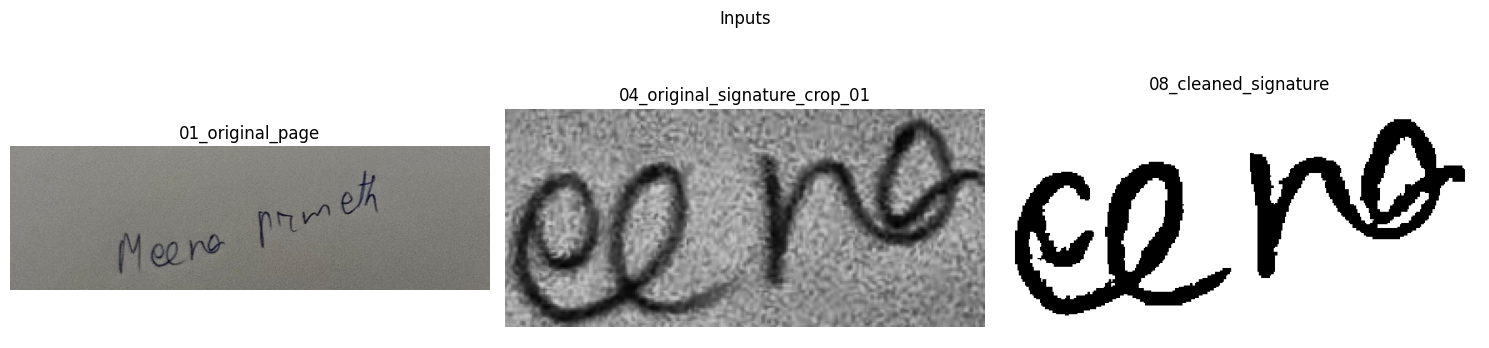

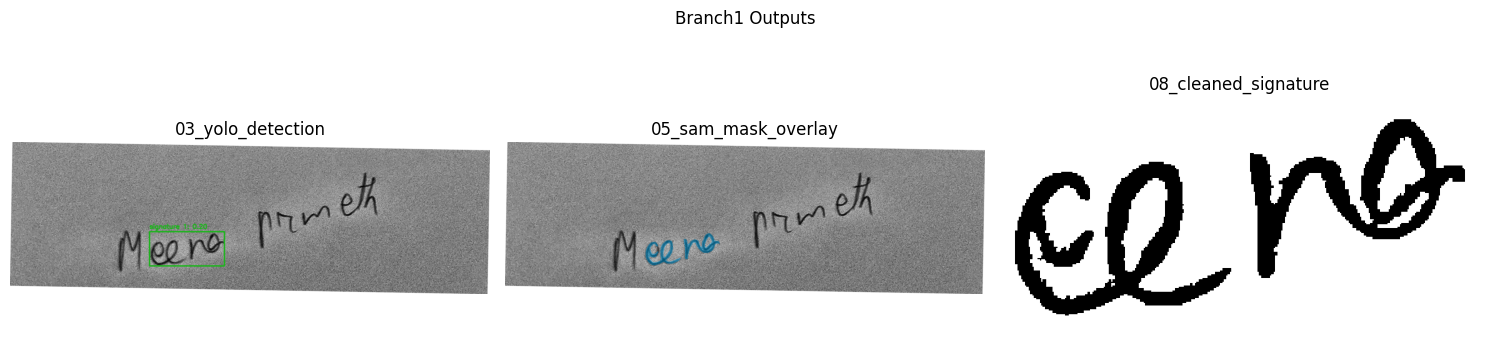

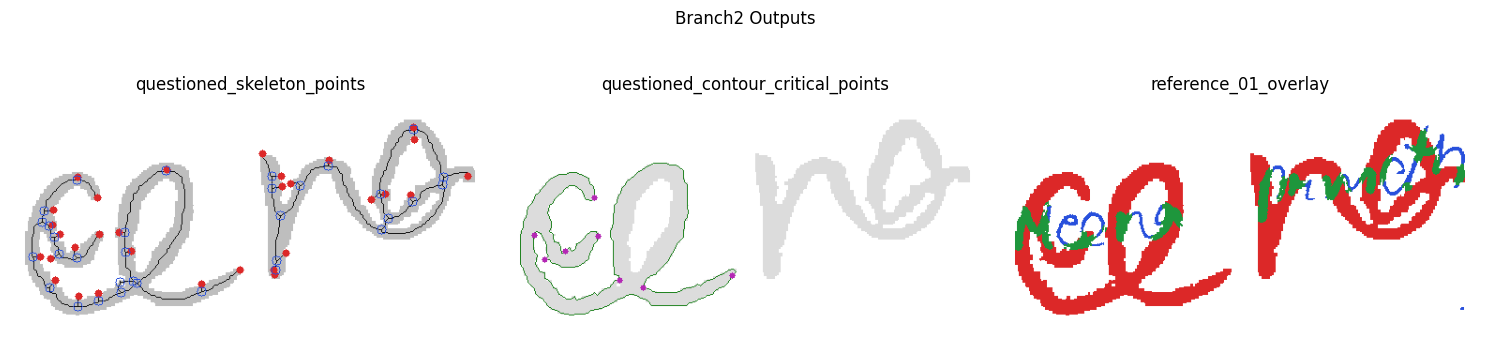

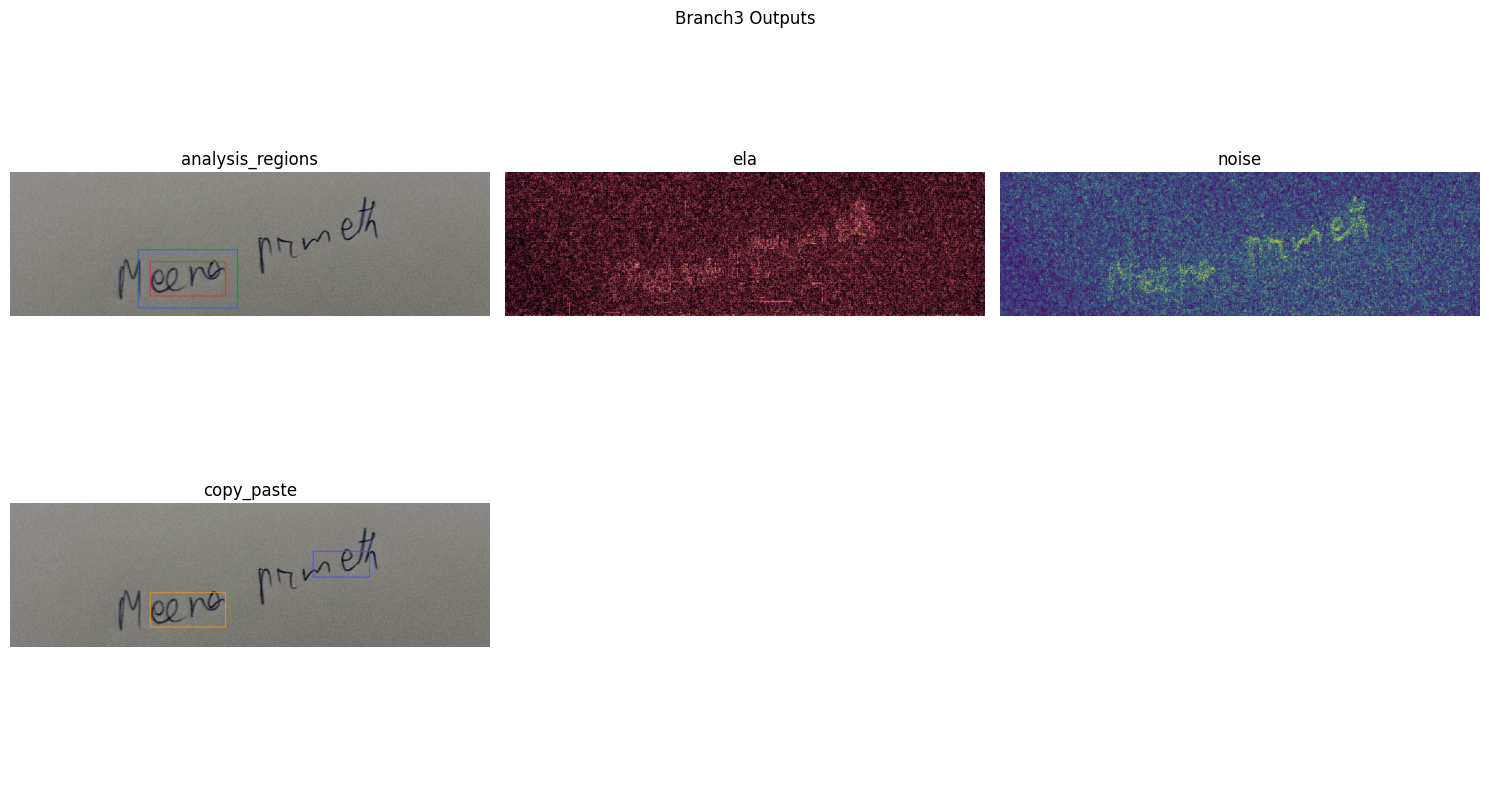

In [39]:
# ## Cell 6 — Show the input and branch-output evidence images
#
# Images are read from the same run. Missing optional visual files are skipped
# without affecting the JSON fusion.

# %%
import math
import matplotlib.pyplot as plt
from PIL import Image

for group_name, image_paths in fusion_bundle["images"].items():
    if not image_paths:
        print(group_name, ": no saved images found")
        continue

    columns = min(3, len(image_paths))
    rows = math.ceil(len(image_paths) / columns)
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(5 * columns, 4 * rows),
    )
    axes = [axes] if len(image_paths) == 1 else axes.ravel()

    for axis, image_path in zip(axes, image_paths):
        axis.imshow(Image.open(image_path))
        axis.set_title(Path(image_path).stem)
        axis.axis("off")
    for axis in axes[len(image_paths):]:
        axis.axis("off")

    figure.suptitle(group_name.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


In [40]:
# ## Cell 7 — Enter the OpenAI API key securely
#
# An OpenAI API call is required for both reports. `getpass` hides the key while
# you type, and the key remains only in this Colab runtime.

# %%
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass(
        "Enter your OpenAI API key: "
    ).strip()

if not os.environ["OPENAI_API_KEY"]:
    raise ValueError("An OpenAI API key is required.")

print("OpenAI API key is available in runtime memory.")

Enter your OpenAI API key: ··········
OpenAI API key is available in runtime memory.


In [41]:
# ## Cell 8 — Generate the senior and technical reports with OpenAI
#
# Two separate prompts are used because the audiences need different depth.
# Only compact structured evidence is sent; saved evidence images are not sent.
# The returned reports are checked for required sections and unsupported claims.

# %%
openai_reports = generate_required_reports(
    fusion_bundle
)

print("OpenAI reports generated with:")
print(json.dumps(openai_reports["metadata"], indent=2))


OpenAI reports generated with:
{
  "provider": "OpenAI",
  "model": "gpt-5.6-terra",
  "reports_generated": 2,
  "images_sent_to_model": false
}


In [42]:
# ## Cell 9 — Display both reports

# %%
from IPython.display import Markdown, display

display(Markdown(openai_reports["senior_report"]))
display(Markdown(openai_reports["technical_report"]))

# Senior Stakeholder Report

## Executive conclusion

**Manual review is required.** The authoritative deterministic fusion result is **manual_review**, with a fused review risk of **0.279573** and a **quality_limited** status.

Branches 1 and 2 both indicate comparative inconsistency, while Branch 3 did not trigger a digital-reuse warning. The fusion process also states that a lower-priority output was blocked by evidence-quality or validation limitations. This result is a review-priority synthesis and should direct human examination rather than resolve the matter.

## Three-branch summary

- **Branch 1 — Learned verification:** **manual_review**; overall risk **0.352259**.  
  The Siamese status was **elevated_inconsistency**, and available indicators require human comparison. Its verification contribution was down-weighted because external generalization was weak; the document also had one or more quality warnings. Component risks were verification **0.686579**, quality **0.160484**, forensic **0.506769**, and duplicate **0.184648**.

- **Branch 2 — Structural AI:** Relative status **below_observed_reference_variation**; branch risk **0.532351**.  
  The questioned mean combined shape similarity was **0.58423187**, compared with a reference similarity median of **0.66175204** and 10th percentile of **0.63057609**, across **3** reference pairs. Questioned-reference combined shape similarities were **0.5554656**, **0.58977695**, and **0.60745307**.

- **Branch 3 — Document forensics:** **no_elevated_indicators**; overall screening risk **0.075921**.  
  No configured screening threshold was exceeded, but the branch expressly states that editing is not ruled out. Copy/paste screening recorded **4** outside-source good matches, **0** RANSAC inliers, a RANSAC inlier ratio of **0.0**, and no possible second location. Compression and noise findings remain screening evidence subject to stated limitations.

## Business implications

- Do not treat this case as cleared for a lower-priority disposition solely because Branch 3 reported no elevated indicators.
- Prioritize qualified human comparison of the questioned signature against the available references, with attention to the comparative inconsistency indicated by Branches 1 and 2.
- Evidence-quality and validation limitations reduce the suitability of automated output as a standalone basis for a consequential decision.
- The fusion used effective weights of **0.599386** for Branch 1, **0.083296** for Branch 2, and **0.317318** for Branch 3, reflecting branch reliabilities of **0.839516**, **0.15**, and **1.0**, respectively.

## Recommended actions

1. Route the case for qualified human examination and comparative review of the questioned signature and the **3** available references.
2. Review the image/document quality warnings and the stated weak untouched CEDAR generalization affecting the learned-verification output.
3. Preserve the source document, questioned-signature crop, references, and processing record for examiner review.
4. Treat document-forensics results as screening context only. In particular, account for the stated limitations that PDF rendering, scanning, image resizing, repeated compression, ink density, paper texture, shadows, and compression can affect observed compression or noise patterns.
5. Do not make a consequential disposition from automated outputs without qualified human examination.

## Limitations and disclaimer

The deterministic fusion conclusion is **manual_review**, not a probability or finding of authenticity, forgery, editing, intent, or legal validity.

This report is not an authenticity, forgery, intent, or legal-validity determination. Model outputs and document-forensics outputs are screening evidence, not legal or forensic conclusions. The absence of an elevated Branch 3 indicator does not establish that editing did not occur.

Consequential use requires qualified human examination.

# Technical Fusion Report

## Scope and evidence

Case `20260728T161842_854206Z` was assessed through a deterministic three-branch review fusion:

1. Learned verification and quality screening;
2. Structural AI comparison against three references;
3. Document-forensics screening for digital-reuse, compression, and noise indicators.

The authoritative deterministic fusion result is `manual_review`, with a fused review risk of `0.279573`. This is a review-priority synthesis, not a probability or a determination concerning authenticity, forgery, editing, intent, or legal validity.

The fusion identifies comparative inconsistency indicators in Branches 1 and 2. Branch 3 reported `no_elevated_indicators` for its available digital-forensics screening methods. The absence of an elevated Branch 3 indicator does not rule out editing or other document-processing history.

## Branch 1 — Learned verification and quality

Branch 1 returned `manual_review` with overall risk `0.352259`. Its reported component risks were:

| Component | Risk |
|---|---:|
| Verification | `0.686579` |
| Quality | `0.160484` |
| Forensic | `0.506769` |
| Duplicate | `0.184648` |

The branch reported that available indicators require human comparison and assigned the Siamese result the status `elevated_inconsistency`. However, its interpretation was expressly limited: the Siamese score could not support a provisional-consistency outcome because untouched CEDAR generalization was weak.

The branch also reported one or more document-quality warnings and stated that the verification contribution was down-weighted because external generalization is weak. Although the branch-level reliability field is `null`, the deterministic fusion assigned Branch 1 a reliability of `0.839516`, producing an effective fusion weight of `0.599386` from its configured weight of `0.45`.

Accordingly, Branch 1 provides a comparatively influential review indicator in the fused result, but its learned-model output remains quality- and validation-limited screening evidence requiring human comparison.

## Branch 2 — Structural AI

Branch 2 compared the questioned signature with three references. The combined shape-similarity values were:

| Reference index | Combined shape similarity |
|---|---:|
| 1 | `0.5554656` |
| 2 | `0.58977695` |
| 3 | `0.60745307` |

The reported questioned similarity summary was:

| Measure | Value |
|---|---:|
| Mean | `0.58423187` |
| Median | `0.58977695` |
| Minimum | `0.5554656` |
| Maximum | `0.60745307` |

The reference set contained `3` reference pairs, with a reference-similarity median of `0.66175204` and 10th percentile of `0.63057609`. The branch’s reported relative status was `below_observed_reference_variation`.

The structural comparison used normalized metric weights of `0.15` for Hu, `0.2` for Fourier, `0.25` for shape context, `0.15` for contour, `0.15` for graph, and `0.1` for critical points for each reference comparison. Across the three comparisons, Fourier, shape-context, graph, and critical-point similarities were generally higher than the Hu and contour similarities. In particular, contour similarity was `0.0`, `0.00029693`, and `0.01211119` for references 1 through 3, respectively, while Hu similarity was `0.08836571`, `0.10708591`, and `0.15936768`.

The deterministic fusion assigned Branch 2 a branch risk of `0.532351`. Its configured weight was `0.35`, but its reported reliability was `0.15`, yielding an effective weight of `0.083296`. Thus, despite being one of the two branches contributing a review indicator, Branch 2 had substantially reduced influence in the final fusion because of its reported reliability.

## Branch 3 — Document forensics

Branch 3 returned `no_elevated_indicators` with overall screening risk `0.075921`. Its component risks were:

| Component | Risk |
|---|---:|
| Copy/paste | `0.020313` |
| Compression | `0.088436` |
| Noise | `0.255622` |
| Duplicate | `0.0` |

Available evidence coverage was `1.0`. The available methods included crop-to-page ORB matching, multiscale template matching, compression analysis, noise analysis, reference hashing, and reference ORB comparisons. There were `3` available reference ORB sources and `3` reference comparisons.

For crop-to-page reuse screening, the crop had `232` keypoints and the page had `1479` keypoints. There were `4` outside-source good matches, `0` RANSAC inliers, and a RANSAC inlier ratio of `0.0`. The template match score was `0.0585`, at template scale `0.75`, with phase response `0.03379`. The system reported `possible_second_location: false`; no detection method or projected polygon was reported.

Compression screening reported an inside-signature ELA mean of `0.534738`, compared with an outside-signature ELA mean of `0.416325` and standard deviation of `0.535588`. The local ELA z-score was `0.22109`. The page blockiness ratio was `1.475522`, based on a block-boundary difference of `7.23416` and nonboundary difference of `4.902782`; reported JPEG quality was `90`.

Noise analysis reported an inside residual standard deviation of `5.654514`, surrounding residual standard deviation of `4.976085`, and residual-standard-deviation ratio of `1.136338`. The absolute residual mean difference was `0.004876`. The inside flat-pixel count was `1306`, the surrounding flat-pixel count was `2468`, and the flat-gradient threshold was `12.0`.

The branch reason states: “No configured screening threshold was exceeded; editing is not ruled out.” Its ELA and noise results are expressly limited as non-specific screening indicators. PDF rendering, scanning, resizing, repeated compression, ink density, paper texture, shadows, and scanning can produce similar patterns. Therefore, Branch 3’s lack of an elevated indicator is not corroboration that no editing or document alteration occurred.

## Fusion method and result

The fusion type was `deterministic_three_branch_review_fusion`. The configured, reliability-adjusted effective weights were:

| Branch | Branch risk | Configured weight | Reliability | Effective weight |
|---|---:|---:|---:|---:|
| Branch 1 | `0.352259` | `0.45` | `0.839516` | `0.599386` |
| Branch 2 | `0.532351` | `0.35` | `0.15` | `0.083296` |
| Branch 3 | `0.075921` | `0.2` | `1.0` | `0.317318` |

The fused review risk was `0.279573`, and the deterministic conclusion was `manual_review`. This conclusion follows the configured deterministic fusion, including its reliability adjustments and the stated restriction that a lower-priority output was blocked by evidence-quality or validation limitations.

Cross-branch agreement was partial. Branches 1 and 2 both produced review indicators associated with comparative inconsistency, while Branch 3 did not trigger a digital-reuse warning. The reported review-indicator count was `2`. This is corroboration between two comparative branches, but Branch 2’s impact was reduced by its `0.15` reliability, and Branch 1 carries explicit external-generalization and quality limitations. Branch 3 provides no elevated digital-forensics indicator under the available methods, but that finding neither resolves nor negates the comparative indicators.

## Evidence gaps

- Branch 1 reported weak untouched CEDAR generalization, limiting interpretation of the Siamese verification result.
- Branch 1 reported one or more document-quality warnings; the supplied evidence does not further characterize those warnings.
- The Branch 1 branch-level reliability field is `null`, although the deterministic fusion reports a reliability of `0.839516`.
- Branch 2 was limited to three reference comparisons and three reference pairs. The supplied evidence does not provide additional reference samples, collection conditions, or variation context beyond the reported reference-similarity values.
- Branch 2 had a reported reliability of `0.15`, limiting its effective fusion contribution despite its comparative inconsistency indicator.
- Branch 3 provides screening results rather than specific attribution. Its ELA and noise analyses are expressly non-specific to editing.
- Crop-to-page and template screening did not report a possible second location, but such screening does not establish the absence of other document-processing mechanisms.
- The supplied evidence does not include original acquisition files, source-device information, document-production history, examination of physical ink or paper, or qualified human visual comparison findings.

## Validation recommendations

- Conduct qualified human examination of the questioned signature and the available reference material, with attention to the comparative inconsistency indicators reported by Branches 1 and 2.
- Review the Branch 1 quality warnings and assess whether image quality, preprocessing, or capture conditions materially affect comparison.
- Expand the reference set where possible and evaluate the questioned item against additional known reference material obtained under documented conditions.
- Review the structural metrics at the feature level, including the low reported Hu and contour similarities relative to the other reported metric similarities.
- If available, examine original source files and document-production materials rather than relying only on rendered, scanned, resized, or repeatedly compressed derivatives.
- Treat the document-forensics outputs as screening evidence and interpret ELA, noise, template, and feature-matching results in light of their stated limitations.
- Validate model behavior on material representative of the intended operational setting before assigning greater interpretive weight to learned verification outputs.

## Technical disclaimer

This report is a technical review-priority synthesis based only on the supplied outputs. The deterministic result of `manual_review` and fused review risk of `0.279573` are not a probability or a finding of authenticity, forgery, editing, intent, or legal validity.

Model and screening outputs are not legal or forensic conclusions. The lack of elevated indicators in Branch 3 does not prove that editing did not occur. Any consequential use requires qualified human examination and consideration of the underlying materials, acquisition history, reference material, and applicable professional and legal requirements.

BRANCH FUSION COMPLETED
Conclusion: manual_review
Fused review risk: 0.279573

Saved outputs:
- fusion_result: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/branch_fusion_result.json
- report_evidence: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/report_evidence.json
- senior_report: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/senior_stakeholder_report.md
- technical_report: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/technical_fusion_report.md
- report_metadata: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/report_metadata.json
- dashboard: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260728T161842_854206Z/branch_fusion/branch_fusion_dashboard.png


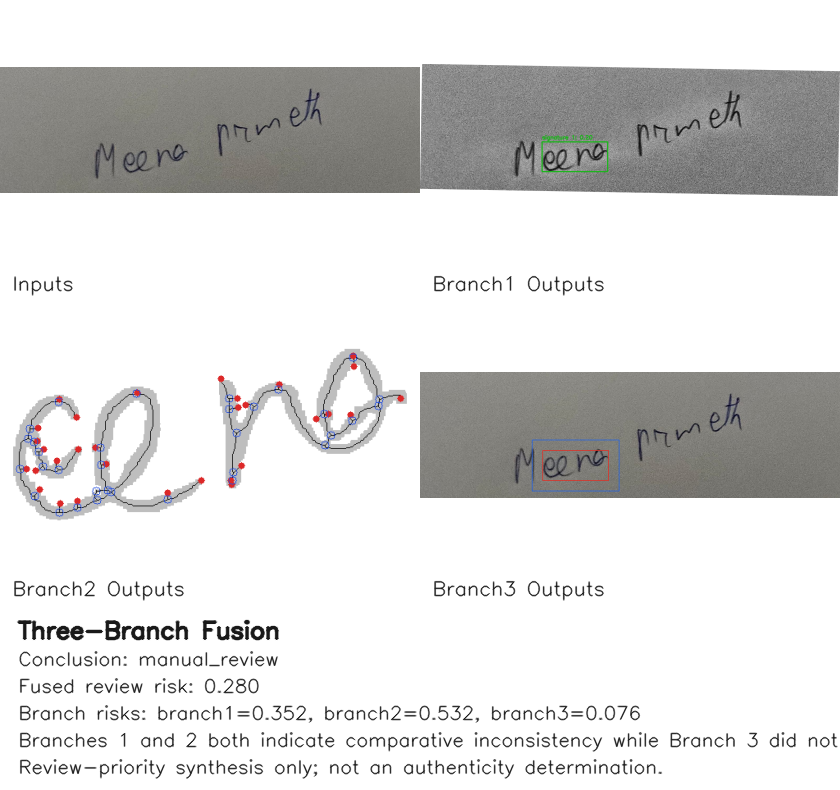


This is a prototype review-priority synthesis, not an authenticity, forgery, editing, intent, or legal-validity determination.


In [43]:
# %% [markdown]
# ## Cell 10 — Save reports, fusion JSON, evidence JSON, and dashboard
#
# Everything is written into a new `branch_fusion` subfolder inside the selected
# run. The dashboard includes representative input and output images.

# %%
saved_fusion_paths = save_branch_fusion_outputs(
    fusion_bundle,
    openai_reports,
)

print("BRANCH FUSION COMPLETED")
print("=======================")
print("Conclusion:", fusion_result["conclusion"])
print(
    "Fused review risk:",
    fusion_result["fused_review_risk"],
)
print("\nSaved outputs:")
for artifact_name, artifact_path in saved_fusion_paths.items():
    print(f"- {artifact_name}: {artifact_path}")

# Display the saved dashboard as the final visual summary.
display(
    Image.open(saved_fusion_paths["dashboard"])
)

print(
    "\nThis is a prototype review-priority synthesis, "
    "not an authenticity, forgery, editing, intent, or "
    "legal-validity determination."
)